In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("/content/customer_retail csv file.csv")

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [3]:
print(df.isnull().sum())
df = df.dropna()

InvoiceNo           0
StockCode           0
Description      1371
Quantity            0
InvoiceDate         0
UnitPrice           1
CustomerID     109831
Country             1
dtype: int64


In [4]:
# Required features
data = df[['Quantity', 'UnitPrice', 'Country']]

print(data.head())

   Quantity  UnitPrice         Country
0         6       2.55  United Kingdom
1         6       3.39  United Kingdom
2         8       2.75  United Kingdom
3         6       3.39  United Kingdom
4         6       3.39  United Kingdom


In [5]:
encoder = LabelEncoder()

data['Country'] = encoder.fit_transform(data['Country'])

/tmp/ipykernel_3147/338270505.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Country'] = encoder.fit_transform(data['Country'])


In [6]:
# Total purchase value
df['PurchaseValue'] = df['Quantity'] * df['UnitPrice']

# Target variable
df['CustomerClass'] = np.where(
    df['PurchaseValue'] > df['PurchaseValue'].median(),
    1,
    0
)

y = df['CustomerClass']

X = data

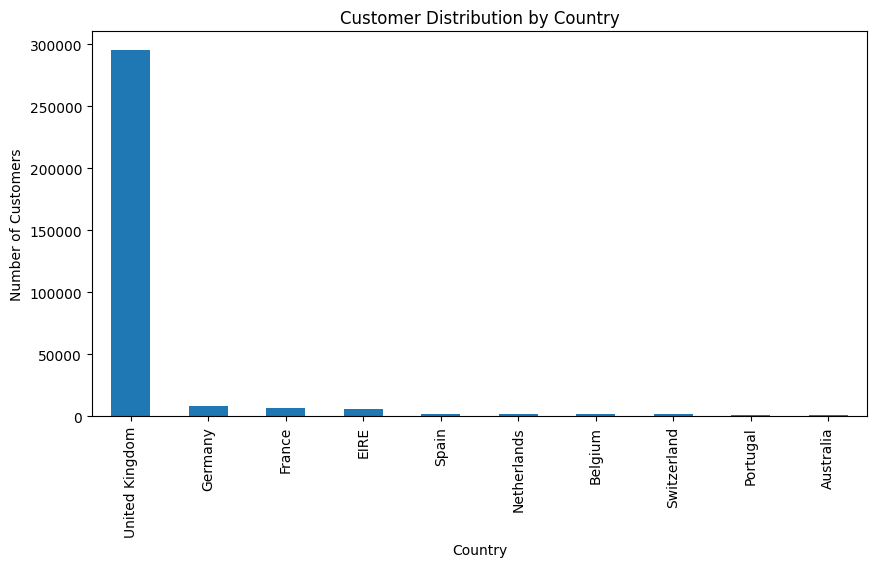

In [7]:
country_counts = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,5))
country_counts.plot(kind='bar')
plt.title("Customer Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##logitics Regression

In [9]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [10]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7590466066803407


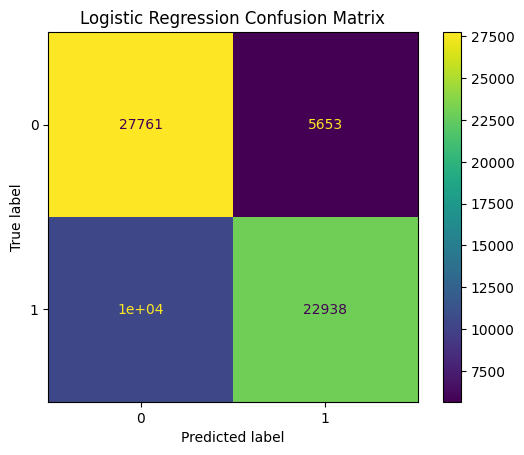

In [11]:
cm_lr = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

##Decision Tree Classifier

In [12]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [13]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


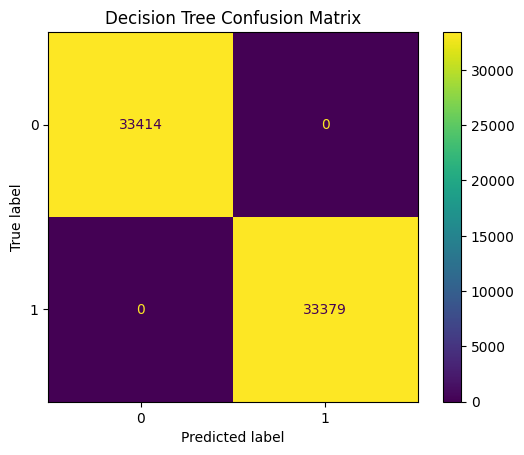

In [14]:
cm_dt = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()

##K-Nearest Neighbors (KNN)

In [15]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

In [16]:
knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9990567873878999


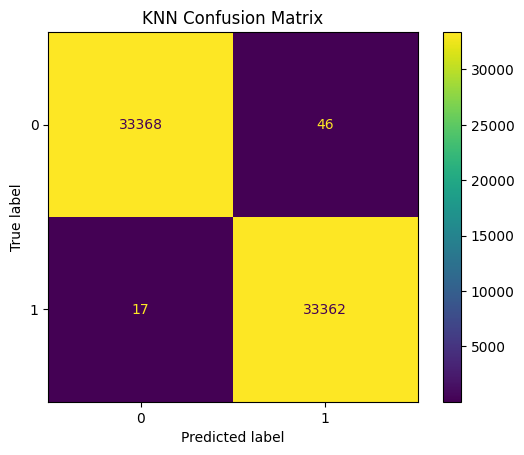

In [17]:
cm_knn = confusion_matrix(y_test, knn_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot()

plt.title("KNN Confusion Matrix")
plt.show()

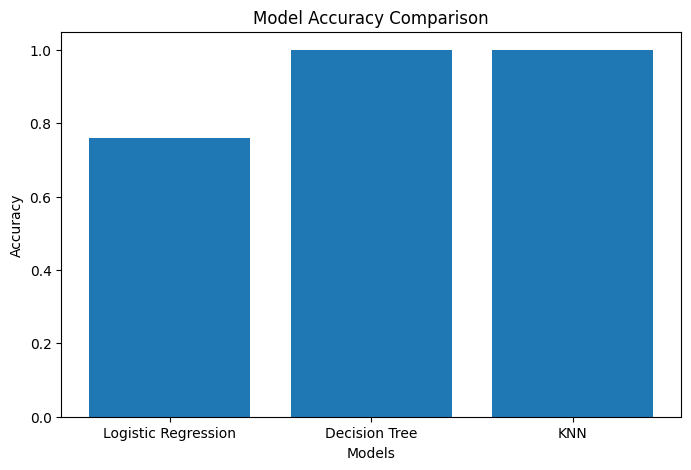

In [18]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'KNN'
]

accuracies = [
    lr_accuracy,
    dt_accuracy,
    knn_accuracy
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

Conclusion

Logistic Regression performs well when the relationship between features and target is mostly linear.

Decision Tree Classifier can capture complex patterns and is easy to interpret.

K-Nearest Neighbors (KNN) classifies data based on similarity between observations.

By comparing the accuracy scores and confusion matrices, we can identify the model that performs best on the customer retail dataset. This project demonstrates the complete Machine Learning workflow including data preprocessing, visualization, model training, evaluation, and comparison.